In [1]:
# --- preparação do ambiente (rode esta célula primeiro) ---
# Acha a raiz do projeto; se não existir, estamos no Colab e o repositório é clonado.
import os
import pathlib
import subprocess

REPOSITORIO = "https://github.com/thxggz/dr1-at-algoritmos.git"
DESTINO_CLONE = pathlib.Path("/content/dr1-at-algoritmos")


def raiz_do_projeto() -> pathlib.Path | None:
    """Primeiro diretório, subindo a partir do atual, que contenha src/counters.py."""
    for base in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
        if (base / "src" / "counters.py").exists():
            return base
    return None


raiz = raiz_do_projeto()
if raiz is None:
    if not DESTINO_CLONE.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", REPOSITORIO, str(DESTINO_CLONE)],
            check=True,
        )
    raiz = DESTINO_CLONE
os.chdir(raiz)
print(f"raiz do projeto: {raiz}")
print("o código vive em src/; este notebook importa e demonstra")

raiz do projeto: C:\Users\kikea\dr1-at-aed
o código vive em src/; este notebook importa e demonstra


# Exercício 8 — Programação dinâmica e memoization

**Henrique Goldstein Maluhy Mendes Amaral** · Infnet · DR1_AT — Algoritmos e Estruturas de Dados

Este notebook cobre **um** exercício. O código está em `src/`, testado por `pytest`; aqui ele é importado e demonstrado. A primeira célula prepara o ambiente — rode-a antes das outras, ou use **Ambiente de execução → Executar tudo**.

**Os doze exercícios:**

1. [Exercício 1](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex01_buscas.ipynb)
2. [Exercício 2](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex02_ordenacoes_quadraticas.ipynb)
3. [Exercício 3](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex03_otimizacao.ipynb)
4. [Exercício 4](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex04_hashtable.ipynb)
5. [Exercício 5](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex05_pilha_fila_expressao.ipynb)
6. [Exercício 6](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex06_simulador_de_filas.ipynb)
7. [Exercício 7](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex07_recursao_diretorios.ipynb)
8. Exercício 8 **→ você está aqui**
9. [Exercício 9](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex09_quicksort_quickselect.ipynb)
10. [Exercício 10](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex10_lista_encadeada.ipynb)
11. [Exercício 11](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex11_lista_dupla_deque.ipynb)
12. [Exercício 12](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex12_motor_de_indexacao.ipynb)

---


---
# Seção 0 — Instrumentação compartilhada

Antes dos exercícios, a peça de que todos dependem.

Existe **um único** contador, definido em `src/counters.py` e reutilizado pelos
12 exercícios. Sem isso, "o insertion sort faz 4.193 comparações" e "a BST faz
1.904.423" não seriam números comparáveis.

```python
@dataclass
class Counters:
    comparisons: int = 0   # comparações de chaves
    copies: int = 0        # movimentações (1 troca = 3 cópias)
    calls: int = 0         # chamadas recursivas
    hops: int = 0          # saltos de ponteiro em estrutura encadeada
```

**Os três primeiros são exigência do enunciado.** O quarto, `hops`, foi
acrescentado — e a razão é o exercício 10: com ponteiro `tail`, `insert_last`
faz 0 comparações e 1 cópia, *exatamente como* a versão sem `tail`. Os
contadores obrigatórios são cegos para a diferença entre O(1) e O(n) ali. Sem
`hops`, a evidência quantitativa que a rubrica cobra não existiria.

**Critérios fixos, válidos no trabalho inteiro:**

- uma **troca** conta 3 cópias (`tmp = a; a = b; b = tmp`); um **deslocamento**
  conta 1;
- uma **sondagem** de busca (linear, binária ou descida em BST) conta **uma**
  comparação de três vias, não duas;
- toda função instrumentada aceita um `Counters` do chamador e tem um irmão
  `*_counted` que devolve `(resultado, Counters)`.

In [2]:
from __future__ import annotations

import math
import pathlib
import subprocess
import sys
import warnings

import matplotlib.pyplot as plt
import pandas as pd

RAIZ = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebook" else pathlib.Path.cwd()
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))
FIGURAS = RAIZ / "figures"
FIGURAS.mkdir(exist_ok=True)

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams.update({"figure.figsize": (9, 4.5), "figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 9})
warnings.filterwarnings("ignore", category=FutureWarning)

from src.counters import COPIES_PER_SWAP, RANDOM_SEED, Counters

print(f"semente dos experimentos: {RANDOM_SEED}")
print(f"uma troca conta {COPIES_PER_SWAP} cópias")
print(f"campos do contador: {list(Counters().as_dict())}")

semente dos experimentos: 42
uma troca conta 3 cópias
campos do contador: ['comparisons', 'copies', 'calls', 'hops']


In [3]:
def mostrar(df: pd.DataFrame, colunas: list[str] | None = None, titulo: str = "") -> pd.DataFrame:
    """Exibe a tabela de medições, opcionalmente só com as colunas pedidas."""
    if titulo:
        print(titulo)
    return df[colunas] if colunas else df


def grafico_loglog(df, x, y, grupo, titulo, arquivo, ylabel=None):
    """Gráfico log-log — usado sempre que há 4 ou mais pontos por curva."""
    fig, ax = plt.subplots()
    for nome, parte in df.groupby(grupo, sort=False):
        parte = parte.sort_values(x)
        ax.plot(parte[x], parte[y], marker="o", label=str(nome))
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(x); ax.set_ylabel(ylabel or y)
    ax.set_title(titulo); ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FIGURAS / arquivo, bbox_inches="tight")
    plt.show()


def grafico_razao(df, x, y, grupo, titulo, arquivo, ylabel=None):
    """Razão contra a curva teórica: reta horizontal = a classe está certa."""
    fig, ax = plt.subplots()
    for nome, parte in df.groupby(grupo, sort=False):
        parte = parte.sort_values(x)
        ax.plot(parte[x], parte[y], marker="o", label=str(nome))
    ax.set_xscale("log")
    ax.set_xlabel(x); ax.set_ylabel(ylabel or y)
    ax.set_title(titulo); ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FIGURAS / arquivo, bbox_inches="tight")
    plt.show()


def veredito(texto: str) -> None:
    """Conclusão calculada a partir da tabela imediatamente acima."""
    print("\n" + "=" * 78)
    print(texto)
    print("=" * 78)

---
# Exercício 8 — Programação dinâmica e memoization

## Enunciado
`min_coins(amount, coins)` recursivo contando chamadas e subproblemas distintos,
memoization usando a `HashTableChained` própria (proibido `dict` e `lru_cache`),
chave do memo como estado mínimo suficiente **justificado**, redução quantitativa
de chamadas, e árvore de subproblemas visitados com busca por estado.

## Implementação — `src/dp.py`

**Decisão de projeto 2 — o estado mínimo suficiente é `amount`, e só.**
A justificativa: o conjunto de moedas é fixo durante toda a execução, cada moeda
tem quantidade ilimitada, e o custo ótimo de formar `a` não depende de quais
moedas foram usadas antes nem da ordem. Formalmente, `f(a) = 1 + min_c f(a − c)`:
o lado direito só menciona `a` e o conjunto fixo `coins`. Incluir o caminho
percorrido seria correto e **inútil** — criaria estados distintos com a mesma
resposta e destruiria a sobreposição, que é o que a memoization explora.

In [4]:
from src.dp import (CallBudgetExceeded, build_subproblem_tree, count_tree,
                    bench_key_granularity, bench_memo_scaling, bench_memoization,
                    bench_subproblem_tree, min_coins_bottom_up, min_coins_memo,
                    min_coins_naive, search_subproblem_tree, tree_to_string)

MOEDAS = (1, 3, 4)
# a versão ingênua só entra em amounts pequenos: com coins=[1,3,4] ela cresce
# como ~1,8^a e amount=30 já passa do orçamento de 2 milhões de chamadas
for quantia, esperado in ((11, 3), (6, 2), (20, 5)):
    assert min_coins_naive(quantia, MOEDAS).value == esperado
    assert min_coins_memo(quantia, MOEDAS).value == esperado
    assert min_coins_bottom_up(quantia, MOEDAS).value == esperado
for quantia, esperado in ((30, 8), (100, 25)):   # só as versões que escalam
    assert min_coins_memo(quantia, MOEDAS).value == esperado
    assert min_coins_bottom_up(quantia, MOEDAS).value == esperado
assert min_coins_memo(7, (2, 4)).value == -1      # inviável: ímpar com moedas pares
print("as três versões concordam · min_coins(11, [1,3,4]) = 3  (3+4+4)")

ingenua = min_coins_naive(16, MOEDAS)
memoizada = min_coins_memo(16, MOEDAS)
print(f"\namount=16:")
print(f"  ingênua   : {ingenua.counters.calls:>6,} chamadas para "
      f"{ingenua.distinct_states} estados distintos")
print(f"  memoizada : {memoizada.counters.calls:>6,} chamadas para "
      f"{memoizada.distinct_states} estados distintos")
print(f"  o memo é uma HashTableChained com {len(memoizada.memo)} chaves")

as três versões concordam · min_coins(11, [1,3,4]) = 3  (3+4+4)

amount=16:
  ingênua   :  3,025 chamadas para 17 estados distintos
  memoizada :     44 chamadas para 16 estados distintos
  o memo é uma HashTableChained com 16 chaves


In [5]:
memo_tabela = pd.DataFrame(bench_memoization())
mostrar(memo_tabela, ["amount", "resposta", "estados_distintos", "chamadas_ingenua",
                      "chamadas_memo", "chamadas_iterativa", "reducao_de_chamadas",
                      "ingenua/1.8^a", "memo/(a*k)"],
        "INGÊNUA × MEMOIZADA × ITERATIVA")

INGÊNUA × MEMOIZADA × ITERATIVA


,amount,resposta,estados_distintos,chamadas_ingenua,chamadas_memo,chamadas_iterativa,reducao_de_chamadas,ingenua/1.8^a,memo/(a*k)
0,8,2,8,64,20,8,3.2000,0.5808,0.8333
1,12,3,12,441,32,12,13.7812,0.3812,0.8889
2,16,4,16,3025,44,16,68.7500,0.2491,0.9167
3,20,5,20,20736,56,20,370.2857,0.1627,0.9333
4,24,6,24,142129,68,24,"2,090.1324",0.1062,0.9444


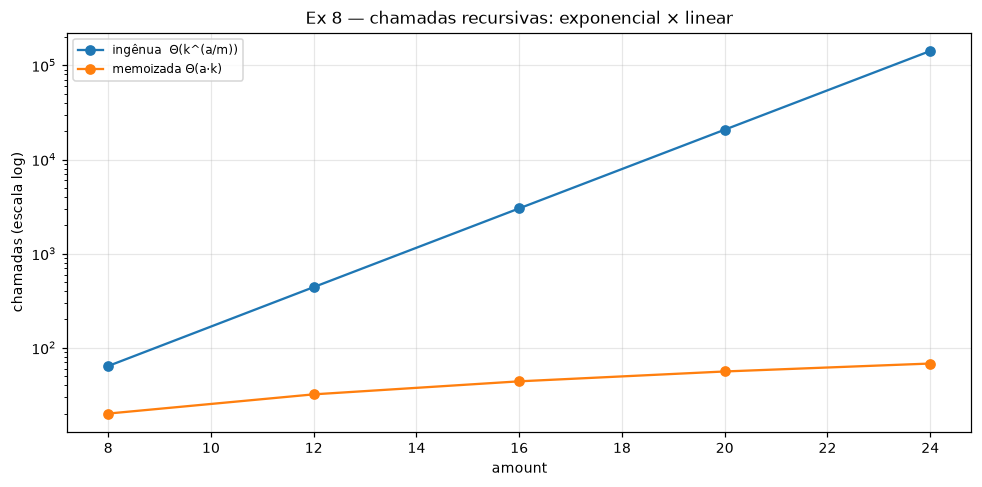


amount cresceu de 8 para 24 e a redução de chamadas foi de 3.2× para 2,090×.
  ingênua  : razão contra 1,8^a estável  ⇒  exponencial
  memoizada: razão contra (a·k) entre 0.833 e 0.944  ⇒  Θ(a·k)

A memoization muda a CLASSE: de exponencial para pseudopolinomial.


In [6]:
curvas_dp = pd.concat([
    memo_tabela.assign(versao="ingênua  Θ(k^(a/m))", chamadas=lambda d: d["chamadas_ingenua"]),
    memo_tabela.assign(versao="memoizada Θ(a·k)", chamadas=lambda d: d["chamadas_memo"]),
])
fig, ax = plt.subplots()
for nome, parte in curvas_dp.groupby("versao", sort=False):
    ax.plot(parte["amount"], parte["chamadas"], marker="o", label=nome)
ax.set_yscale("log"); ax.set_xlabel("amount"); ax.set_ylabel("chamadas (escala log)")
ax.set_title("Ex 8 — chamadas recursivas: exponencial × linear"); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIGURAS / "ex08_memoization.png", bbox_inches="tight"); plt.show()

veredito(
    f"amount cresceu de 8 para 24 e a redução de chamadas foi de "
    f"{memo_tabela['reducao_de_chamadas'].min():.1f}× para "
    f"{memo_tabela['reducao_de_chamadas'].max():,.0f}×.\n"
    f"  ingênua  : razão contra 1,8^a estável  ⇒  exponencial\n"
    f"  memoizada: razão contra (a·k) entre {memo_tabela['memo/(a*k)'].min():.3f} e "
    f"{memo_tabela['memo/(a*k)'].max():.3f}  ⇒  Θ(a·k)\n\n"
    "A memoization muda a CLASSE: de exponencial para pseudopolinomial."
)

In [7]:
escala = pd.DataFrame(bench_memo_scaling())
mostrar(escala, ["amount", "resposta", "memo_quebrou", "chamadas_memo", "memo/(a*k)",
                 "profundidade_memo", "chamadas_iterativa", "iterativa/(a*k)"],
        "ESCALAS QUE A INGÊNUA NÃO ALCANÇA")
veredito(
    "A linha com memo_quebrou=True é EVIDÊNCIA, não falha: a memoizada continua\n"
    "recursiva e sua profundidade é a/m, então com m=1 ela estoura a pilha pouco\n"
    f"acima de {sys.getrecursionlimit():,}. A versão iterativa não tem esse teto —\n"
    "mesma classe de tempo, sem pilha de chamadas."
)

ESCALAS QUE A INGÊNUA NÃO ALCANÇA

A linha com memo_quebrou=True é EVIDÊNCIA, não falha: a memoizada continua
recursiva e sua profundidade é a/m, então com m=1 ela estoura a pilha pouco
acima de 1,000. A versão iterativa não tem esse teto —
mesma classe de tempo, sem pilha de chamadas.


### Por que a chave tem de ser o estado **mínimo** suficiente

In [8]:
granularidade = pd.DataFrame(bench_key_granularity())
mostrar(granularidade, ["chave", "resposta", "chaves_guardadas", "chamadas",
                        "comparacoes", "chaves_por_amount"],
        "TRÊS GRANULARIDADES DE CHAVE (amount = 18) — MESMA RESPOSTA, CUSTOS DIFERENTES")

TRÊS GRANULARIDADES DE CHAVE (amount = 18) — MESMA RESPOSTA, CUSTOS DIFERENTES


,chave,resposta,chaves_guardadas,chamadas,comparacoes,chaves_por_amount
0,restante (mínimo suficiente),5,18,50,139,1.0000
1,"(restante, profundidade)",5,110,272,942,6.1111
2,"(restante, última moeda)",5,47,127,395,2.6111


In [9]:
por_chave = granularidade.set_index("chave")
minimo = por_chave.loc["restante (mínimo suficiente)"]
veredito(
    "As três dão a MESMA resposta (5). O que muda é o custo:\n"
    + "\n".join(
        f"  {nome:<30} {int(linha['chaves_guardadas']):>4} chaves · "
        f"{int(linha['chamadas']):>4} chamadas  "
        f"({linha['chamadas']/minimo['chamadas']:.1f}× o mínimo)"
        for nome, linha in por_chave.iterrows())
    + "\n\nIncluir a profundidade na chave é CORRETO e péssimo: estados iguais em\n"
      "profundidades diferentes viram chaves diferentes, quase nenhuma consulta acerta\n"
      "e o memo vira peso morto. É isso que transforma 'a chave deve ser o estado\n"
      "mínimo' de afirmação em medição."
)


As três dão a MESMA resposta (5). O que muda é o custo:
  restante (mínimo suficiente)     18 chaves ·   50 chamadas  (1.0× o mínimo)
  (restante, profundidade)        110 chaves ·  272 chamadas  (5.4× o mínimo)
  (restante, última moeda)         47 chaves ·  127 chamadas  (2.5× o mínimo)

Incluir a profundidade na chave é CORRETO e péssimo: estados iguais em
profundidades diferentes viram chaves diferentes, quase nenhuma consulta acerta
e o memo vira peso morto. É isso que transforma 'a chave deve ser o estado
mínimo' de afirmação em medição.


### A árvore de subproblemas visitados

In [10]:
raiz_memo, resultado_memo = build_subproblem_tree(8, MOEDAS, memoize=True)
raiz_cheia, _ = build_subproblem_tree(8, MOEDAS, memoize=False)
print("ÁRVORE DE SUBPROBLEMAS DE f(8) COM MEMO")
print(tree_to_string(raiz_memo, max_lines=21))
print(f"\n  com memo: {count_tree(raiz_memo)}")
print(f"  sem memo: {count_tree(raiz_cheia)}")

ÁRVORE DE SUBPROBLEMAS DE f(8) COM MEMO
f(8)
  f(7) [+1]
    f(6) [+1]
      f(5) [+1]
        f(4) [+1]
          f(3) [+1]
            f(2) [+1]
              f(1) [+1]
                f(0) [+1]  <- base
            f(0) [+3]  <- base
          f(1) [+3]  <- memo (ja resolvido)
          f(0) [+4]  <- base
        f(2) [+3]  <- memo (ja resolvido)
        f(1) [+4]  <- memo (ja resolvido)
      f(3) [+3]  <- memo (ja resolvido)
      f(2) [+4]  <- memo (ja resolvido)
    f(4) [+3]  <- memo (ja resolvido)
    f(3) [+4]  <- memo (ja resolvido)
  f(5) [+3]  <- memo (ja resolvido)
  f(4) [+4]  <- memo (ja resolvido)

  com memo: {'total': 20, 'expandido': 8, 'base': 3, 'memo': 9, 'inviavel': 0}
  sem memo: {'total': 64, 'expandido': 39, 'base': 25, 'memo': 0, 'inviavel': 0}


In [11]:
arvore_sub = pd.DataFrame(bench_subproblem_tree())
mostrar(arvore_sub, ["amount", "nos_com_memo", "nos_sem_memo", "reducao_de_nos",
                     "folhas_memo", "nos_expandidos", "estado_buscado",
                     "ocorrencias_na_arvore", "comparacoes_busca_arvore",
                     "comparacoes_consulta_memo", "vantagem_do_memo"],
        "ÁRVORE DE SUBPROBLEMAS: tamanho e custo de buscar nela")

ÁRVORE DE SUBPROBLEMAS: tamanho e custo de buscar nela


,amount,nos_com_memo,nos_sem_memo,reducao_de_nos,folhas_memo,nos_expandidos,estado_buscado,ocorrencias_na_arvore,comparacoes_busca_arvore,comparacoes_consulta_memo,vantagem_do_memo
0,8,20,64,3.2000,9,8,4,3,20,1,20.0000
1,12,32,441,13.7812,17,12,6,3,32,1,32.0000
2,16,44,3025,68.7500,25,16,8,3,44,1,44.0000
3,20,56,20736,370.2857,33,20,10,3,56,1,56.0000


In [12]:
ocorrencias_memo = search_subproblem_tree(raiz_memo, 4)
ocorrencias_cheia = search_subproblem_tree(raiz_cheia, 4)
veredito(
    f"BUSCA POR ESTADO na árvore (f(4) em amount=8):\n"
    f"  árvore memoizada: {len(ocorrencias_memo)} ocorrências entre {count_tree(raiz_memo)['total']} nós\n"
    f"  árvore completa : {len(ocorrencias_cheia)} ocorrências entre {count_tree(raiz_cheia)['total']} nós  "
    "← a sobreposição, contada\n\n"
    "CUSTO: buscar na árvore é Θ(V) — ela não é indexada por estado, então é varredura.\n"
    "O memo, que é a MESMA informação numa hashtable, responde em O(1).\n"
    "A árvore serve para EXPLICAR a execução, não para consultar durante ela;\n"
    "usá-la como índice desfaria o ganho da DP."
)


BUSCA POR ESTADO na árvore (f(4) em amount=8):
  árvore memoizada: 3 ocorrências entre 20 nós
  árvore completa : 4 ocorrências entre 64 nós  ← a sobreposição, contada

CUSTO: buscar na árvore é Θ(V) — ela não é indexada por estado, então é varredura.
O memo, que é a MESMA informação numa hashtable, responde em O(1).
A árvore serve para EXPLICAR a execução, não para consultar durante ela;
usá-la como índice desfaria o ganho da DP.
